## Objective

Construct the final integrated modeling cohort for downstream multi-omic and pharmacogenomic analyses.

The previous notebooks established the structurally harmonized DepMap–GDSC model universe. This notebook evaluates whether those harmonized models have sufficient data availability across the molecular and pharmacological layers required for downstream analysis.

Specifically, this notebook assesses:

- expression data availability;
- somatic mutation data availability;
- DepMap omics profile availability;
- GDSC pharmacological response availability;
- overlap between molecular and pharmacological data layers;
- model retention after applying explicit inclusion criteria.

The main output is a reproducible definition of the integrated modeling cohort.

## Scope

This notebook is part of the infrastructure layer of the project.

It does not perform biological interpretation, dimensionality reduction, clustering, drug selection, resistance-like phenotype definition, signature construction, or predictive modeling.

Those analyses will be performed only after the usable model universe has been explicitly defined.

## Conceptual distinction

The harmonized model universe answers:

> Which DepMap and GDSC models can be structurally matched?

The integrated modeling cohort answers:

> Which harmonized models are actually usable for downstream multi-omic and pharmacogenomic analysis?

This distinction is important because structural overlap does not imply analytical usability.

A model may be harmonized across resources but still lack expression data, mutation data, omics profile metadata, or sufficient pharmacological response information.

## Expected outputs

This notebook will generate:

```text
data/interim/metadata/302_integrated_modeling_cohort.csv
data/interim/metadata/302_cohort_summary.csv
data/interim/metadata/302_model_layer_coverage.csv
```

## Methodological note

All inclusion criteria are defined explicitly and applied after assessing data-layer coverage.

The final cohort should be interpreted as a computationally defined analysis universe, not as a clinically validated cohort or a causal model of drug resistance.

---

In [31]:
# =============================================================================
# Imports
# =============================================================================

from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.paths import Paths

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

## Load input datasets

Load the harmonized model universe together with the molecular and
pharmacological resources required for coverage assessment.

In [32]:
# =============================================================================
# Paths
# =============================================================================

PROJECT_ROOT = Paths.root

METADATA_DIR = Paths.metadata

DEPMAP_DIR = Paths.depmap
GDSC_DIR = Paths.gdsc

# =============================================================================
# Input files
# =============================================================================

harmonized_path = (
    METADATA_DIR /
    "301_harmonized_model_universe.csv"
)

expression_path = (
    DEPMAP_DIR /
    "OmicsExpressionProteinCodingGenesTPMLogp1.csv"
)

mutations_path = (
    DEPMAP_DIR /
    "OmicsSomaticMutations.csv"
)

omics_profiles_path = (
    DEPMAP_DIR /
    "OmicsProfiles.csv"
)

gdsc_path = (
    GDSC_DIR /
    "GDSC2_fitted_dose_response_27Oct23.xlsx"
)

# =============================================================================
# Load datasets
# =============================================================================

harmonized_models = pd.read_csv(harmonized_path)

expression = pd.read_csv(expression_path)

mutations = pd.read_csv(mutations_path)

omics_profiles = pd.read_csv(omics_profiles_path)

gdsc = pd.read_excel(gdsc_path)

print(f"Harmonized models : {harmonized_models.shape}")
print(f"Expression         : {expression.shape}")
print(f"Mutations          : {mutations.shape}")
print(f"Omics profiles     : {omics_profiles.shape}")
print(f"GDSC               : {gdsc.shape}")

C:\Users\paula\AppData\Local\Temp\ipykernel_9572\3448021601.py:49: DtypeWarning: Columns (22,50,56,57,58,59,61) have mixed types. Specify dtype option on import or set low_memory=False.
  mutations = pd.read_csv(mutations_path)


Harmonized models : (968, 8)
Expression         : (1673, 19194)
Mutations          : (718369, 70)
Omics profiles     : (4518, 9)
GDSC               : (242036, 16)


In [33]:
datasets = {
    "harmonized_models": harmonized_models,
    "expression": expression,
    "mutations": mutations,
    "omics_profiles": omics_profiles,
    "gdsc": gdsc,
}

for name, df in datasets.items():
    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)
    print(df.head(3))


harmonized_models
      ModelID SangerModelID  COSMICID CellLineName       OncotreeLineage  \
0  ACH-000001     SIDM00105  905933.0  NIH:OVCAR-3  Ovary/Fallopian Tube   
1  ACH-000002     SIDM00829  905938.0        HL-60               Myeloid   
2  ACH-000004     SIDM00594  907053.0          HEL               Myeloid   

     OncotreePrimaryDisease                   OncotreeSubtype  \
0  Ovarian Epithelial Tumor  High-Grade Serous Ovarian Cancer   
1    Acute Myeloid Leukemia            Acute Myeloid Leukemia   
2    Acute Myeloid Leukemia            Acute Myeloid Leukemia   

                                  CCLEName  
0                          NIHOVCAR3_OVARY  
1  HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  
2   HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE  

expression
   Unnamed: 0  TSPAN6 (7105)  TNMD (64102)  DPM1 (8813)  SCYL3 (57147)  \
0  ACH-001113       4.331992      0.000000     7.364660       2.792855   
1  ACH-001289       4.567424      0.584963     7.106641       2.543496   
2

In [34]:
# =============================================================================
# Column inspection
# =============================================================================

for name, df in {
    "harmonized_models": harmonized_models,
    "expression": expression,
    "mutations": mutations,
    "omics_profiles": omics_profiles,
    "gdsc": gdsc,
}.items():

    print("\n" + "=" * 80)
    print(name)
    print("=" * 80)

    print(list(df.columns[:100]))


harmonized_models
['ModelID', 'SangerModelID', 'COSMICID', 'CellLineName', 'OncotreeLineage', 'OncotreePrimaryDisease', 'OncotreeSubtype', 'CCLEName']

expression
['Unnamed: 0', 'TSPAN6 (7105)', 'TNMD (64102)', 'DPM1 (8813)', 'SCYL3 (57147)', 'C1orf112 (55732)', 'FGR (2268)', 'CFH (3075)', 'FUCA2 (2519)', 'GCLC (2729)', 'NFYA (4800)', 'STPG1 (90529)', 'NIPAL3 (57185)', 'LAS1L (81887)', 'ENPP4 (22875)', 'SEMA3F (6405)', 'CFTR (1080)', 'ANKIB1 (54467)', 'CYP51A1 (1595)', 'KRIT1 (889)', 'RAD52 (5893)', 'BAD (572)', 'LAP3 (51056)', 'CD99 (4267)', 'HS3ST1 (9957)', 'AOC1 (26)', 'WNT16 (51384)', 'HECW1 (23072)', 'MAD1L1 (8379)', 'LASP1 (3927)', 'SNX11 (29916)', 'TMEM176A (55365)', 'M6PR (4074)', 'KLHL13 (90293)', 'CYP26B1 (56603)', 'ICA1 (3382)', 'DBNDD1 (79007)', 'ALS2 (57679)', 'CASP10 (843)', 'CFLAR (8837)', 'TFPI (7035)', 'NDUFAF7 (55471)', 'RBM5 (10181)', 'MTMR7 (9108)', 'SLC7A2 (6542)', 'ARF5 (381)', 'SARM1 (23098)', 'POLDIP2 (26073)', 'PLXND1 (23129)', 'AK2 (204)', 'CD38 (952)', 'FKBP

In [35]:
expression = expression.rename(
    columns={"Unnamed: 0": "ModelID"}
)

In [36]:
omics_profiles["Datatype"].value_counts()

Datatype
wes    1909
rna    1690
wgs     919
Name: count, dtype: int64

In [37]:
# Coverage audit
expr_models = set(expression["ModelID"])

mut_models = set(mutations["ModelID"])

omics_models = set(omics_profiles["ModelID"])

gdsc_models = set(
    harmonized_models.loc[
        harmonized_models["SangerModelID"].isin(
            gdsc["SANGER_MODEL_ID"]
        ),
        "ModelID"
    ]
)

In [38]:
omics_profiles.groupby("Datatype")["ModelID"].nunique()

Datatype
rna    1673
wes    1700
wgs     917
Name: ModelID, dtype: int64

In [39]:
# Summary of coverage
omics_availability = (
    pd.crosstab(
        omics_profiles["ModelID"],
        omics_profiles["Datatype"]
    )
    .gt(0)
    .astype(int)
)

omics_availability.head()

Datatype,rna,wes,wgs
ModelID,,,
ACH-000001,1,1,1
ACH-000002,1,1,0
ACH-000003,1,0,0
ACH-000004,1,1,1
ACH-000005,1,1,1


In [40]:
omics_availability.sum()

Datatype
rna    1673
wes    1700
wgs     917
dtype: int64

In [41]:
omics_availability.mean() * 100

Datatype
rna    83.441397
wes    84.788030
wgs    45.735661
dtype: float64

## Coverage within the harmonized model universe

Assess the availability of molecular and pharmacological data layers
across the harmonized DepMap–GDSC model universe established in
Notebook 21.

Coverage is evaluated relative to the 968 harmonized models and serves
as the basis for defining the final integrated modeling cohort.

In [42]:
# =============================================================================
# Harmonized universe
# =============================================================================

harmonized_model_ids = set(
    harmonized_models["ModelID"]
)

# =============================================================================
# Available models by data layer
# =============================================================================

expr_models = set(
    expression["ModelID"].dropna().unique()
)

mut_models = set(
    mutations["ModelID"].dropna().unique()
)

omics_models = set(
    omics_profiles["ModelID"].dropna().unique()
)

gdsc_sanger_ids = set(
    gdsc["SANGER_MODEL_ID"].dropna().unique()
)

gdsc_models = set(
    harmonized_models.loc[
        harmonized_models["SangerModelID"].isin(gdsc_sanger_ids),
        "ModelID"
    ]
)

# =============================================================================
# Coverage summary
# =============================================================================

coverage_summary = pd.DataFrame({
    "Layer": [
        "Expression",
        "Mutations",
        "Omics Profiles",
        "Drug Response"
    ],
    "Models": [
        len(harmonized_model_ids & expr_models),
        len(harmonized_model_ids & mut_models),
        len(harmonized_model_ids & omics_models),
        len(harmonized_model_ids & gdsc_models),
    ]
})

coverage_summary["CoveragePct"] = (
    coverage_summary["Models"]
    / len(harmonized_model_ids)
    * 100
).round(2)

coverage_summary

,Layer,Models,CoveragePct
0,Expression,714,73.76
1,Mutations,959,99.07
2,Omics Profiles,960,99.17
3,Drug Response,968,100.00


In [43]:
missing_expression = (
    harmonized_model_ids
    - expr_models
)

len(missing_expression)

254

In [44]:
harmonized_models.loc[
    harmonized_models["ModelID"].isin(
        list(missing_expression)
    )
].head(20)

,ModelID,SangerModelID,COSMICID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName
21,ACH-000047,SIDM00274,906869.0,GCIY,Esophagus/Stomach,Esophagogastric Adenocarcinoma,Stomach Adenocarcinoma,GCIY_STOMACH
177,ACH-000309,SIDM01108,909721.0,SK-LU-1,Lung,Non-Small Cell Lung Cancer,Lung Adenocarcinoma,SKLU1_LUNG
440,ACH-000727,SIDM00711,1330973.0,NCI-H2066,Lung,Lung Neuroendocrine Tumor,Small Cell Lung Cancer,NCIH2066_LUNG
482,ACH-000795,SIDM00433,908146.0,MOLT-13,Lymphoid,T-Lymphoblastic Leukemia/Lymphoma,T-Lymphoblastic Leukemia/Lymphoma,MOLT13_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE
623,ACH-001002,SIDM01240,1287706.0,451Lu,Skin,Melanoma,Cutaneous Melanoma,451LU_SKIN
625,ACH-001021,SIDM01237,910850.0,C3A,Liver,Hepatoblastoma,Hepatoblastoma,C3A_LIVER
626,ACH-001023,SIDM01248,910568.0,CGTH-W-1,Head and Neck,Head and Neck Squamous Cell Carcinoma,Head and Neck Squamous Cell Carcinoma,CGTHW1_THYROID
627,ACH-001024,SIDM01228,910853.0,CHL-1,Skin,Melanoma,Melanoma,CHL1_SKIN
628,ACH-001039,SIDM00826,905961.0,COLO 205,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,COLO205_LARGE_INTESTINE
629,ACH-001049,SIDM00953,753547.0,CPC-N,Lung,Lung Neuroendocrine Tumor,Small Cell Lung Cancer,CPCN_LUNG


In [45]:
missing_expression_df = harmonized_models[
    harmonized_models["ModelID"].isin(missing_expression)
]

In [46]:
missing_expression_df["OncotreeLineage"].value_counts()

OncotreeLineage
Lymphoid                     39
Lung                         32
Bone                         24
CNS/Brain                    18
Skin                         17
Head and Neck                16
Kidney                       16
Pleura                       14
Peripheral Nervous System    13
Esophagus/Stomach            11
Myeloid                      11
Ovary/Fallopian Tube          7
Bowel                         6
Soft Tissue                   5
Breast                        5
Cervix                        3
Pancreas                      3
Vulva/Vagina                  3
Liver                         2
Biliary Tract                 2
Thyroid                       2
Bladder/Urinary Tract         2
Prostate                      1
Other                         1
Testis                        1
Name: count, dtype: int64

In [47]:
missing_expression_df["OncotreePrimaryDisease"].value_counts().head(20)

OncotreePrimaryDisease
Diffuse Glioma                           18
Lung Neuroendocrine Tumor                18
Ewing Sarcoma                            17
Renal Cell Carcinoma                     16
Mature B-Cell Neoplasms                  16
Melanoma                                 16
Head and Neck Squamous Cell Carcinoma    14
Pleural Mesothelioma                     14
Non-Small Cell Lung Cancer               14
Neuroblastoma                            13
B-Lymphoblastic Leukemia/Lymphoma         7
Esophagogastric Adenocarcinoma            7
T-Lymphoblastic Leukemia/Lymphoma         7
Colorectal Adenocarcinoma                 6
Acute Myeloid Leukemia                    6
Ovarian Epithelial Tumor                  6
Invasive Breast Carcinoma                 5
Esophageal Squamous Cell Carcinoma        4
Chondrosarcoma                            4
Non-Hodgkin Lymphoma                      4
Name: count, dtype: int64

In [48]:
coverage_df = harmonized_models.copy()

coverage_df["has_expression"] = (
    coverage_df["ModelID"].isin(expr_models)
)

coverage_df["has_mutations"] = (
    coverage_df["ModelID"].isin(mut_models)
)

coverage_df["has_omics_profile"] = (
    coverage_df["ModelID"].isin(omics_models)
)

In [49]:
(
    coverage_df
    .groupby("OncotreeLineage")["has_expression"]
    .mean()
    .sort_values()
    * 100
)

OncotreeLineage
Other                          0.000000
Pleura                        33.333333
Vulva/Vagina                  40.000000
Bone                          41.463415
Biliary Tract                 50.000000
Kidney                        54.285714
Peripheral Nervous System     58.064516
Head and Neck                 61.904762
Testis                        66.666667
CNS/Brain                     67.272727
Skin                          68.518519
Soft Tissue                   68.750000
Lymphoid                      68.800000
Myeloid                       74.418605
Cervix                        78.571429
Lung                          81.065089
Esophagus/Stomach             82.258065
Ovary/Fallopian Tube          82.926829
Thyroid                       86.666667
Liver                         86.666667
Prostate                      87.500000
Bowel                         87.755102
Bladder/Urinary Tract         88.888889
Pancreas                      90.322581
Breast                  

## RNA-seq coverage loss within the harmonized universe

Expression availability is the main source of model loss within the harmonized DepMap–GDSC universe.

Although mutation data, omics profile metadata, and GDSC pharmacological response show near-complete coverage, only 715 of 968 harmonized models have expression data available in the current DepMap expression matrix.

This loss does not appear to be caused by malformed ModelID values or by non-default expression profiles. Instead, it reflects data-layer availability differences across resources.

Because downstream transcriptomic and pharmacogenomic analyses require expression data, this coverage loss must be explicitly documented before defining the integrated modeling cohort.

---

## Coverage by lineage

To evaluate whether RNA-seq availability is uniformly distributed across the harmonized model universe, coverage is assessed separately for each Oncotree lineage.

This analysis helps identify potential lineage-specific coverage biases that may affect downstream transcriptomic and pharmacogenomic analyses.

Coverage is defined as the proportion of harmonized models within each lineage that have expression data available in the current DepMap RNA-seq resource.

In [50]:
# =============================================================================
# RNA-seq coverage by lineage
# =============================================================================

lineage_coverage = (
    coverage_df
    .groupby("OncotreeLineage")
    .agg(
        HarmonizedModels=("ModelID", "nunique"),
        ExpressionModels=("has_expression", "sum")
    )
    .reset_index()
)

lineage_coverage["MissingModels"] = (
    lineage_coverage["HarmonizedModels"]
    - lineage_coverage["ExpressionModels"]
)

lineage_coverage["CoveragePct"] = (
    100
    * lineage_coverage["ExpressionModels"]
    / lineage_coverage["HarmonizedModels"]
).round(1)

lineage_coverage = (
    lineage_coverage
    .sort_values(
        by=["CoveragePct", "HarmonizedModels"],
        ascending=[True, False]
    )
    .reset_index(drop=True)
)

lineage_coverage

,OncotreeLineage,HarmonizedModels,ExpressionModels,MissingModels,CoveragePct
0,Other,1,0,1,0.0
1,Pleura,21,7,14,33.3
2,Vulva/Vagina,5,2,3,40.0
3,Bone,41,17,24,41.5
4,Biliary Tract,4,2,2,50.0
5,Kidney,35,19,16,54.3
6,Peripheral Nervous System,31,18,13,58.1
7,Head and Neck,42,26,16,61.9
8,Testis,3,2,1,66.7
9,CNS/Brain,55,37,18,67.3


In [51]:
lineage_coverage[
    lineage_coverage["CoveragePct"] < 80
]

,OncotreeLineage,HarmonizedModels,ExpressionModels,MissingModels,CoveragePct
0,Other,1,0,1,0.0
1,Pleura,21,7,14,33.3
2,Vulva/Vagina,5,2,3,40.0
3,Bone,41,17,24,41.5
4,Biliary Tract,4,2,2,50.0
5,Kidney,35,19,16,54.3
6,Peripheral Nervous System,31,18,13,58.1
7,Head and Neck,42,26,16,61.9
8,Testis,3,2,1,66.7
9,CNS/Brain,55,37,18,67.3


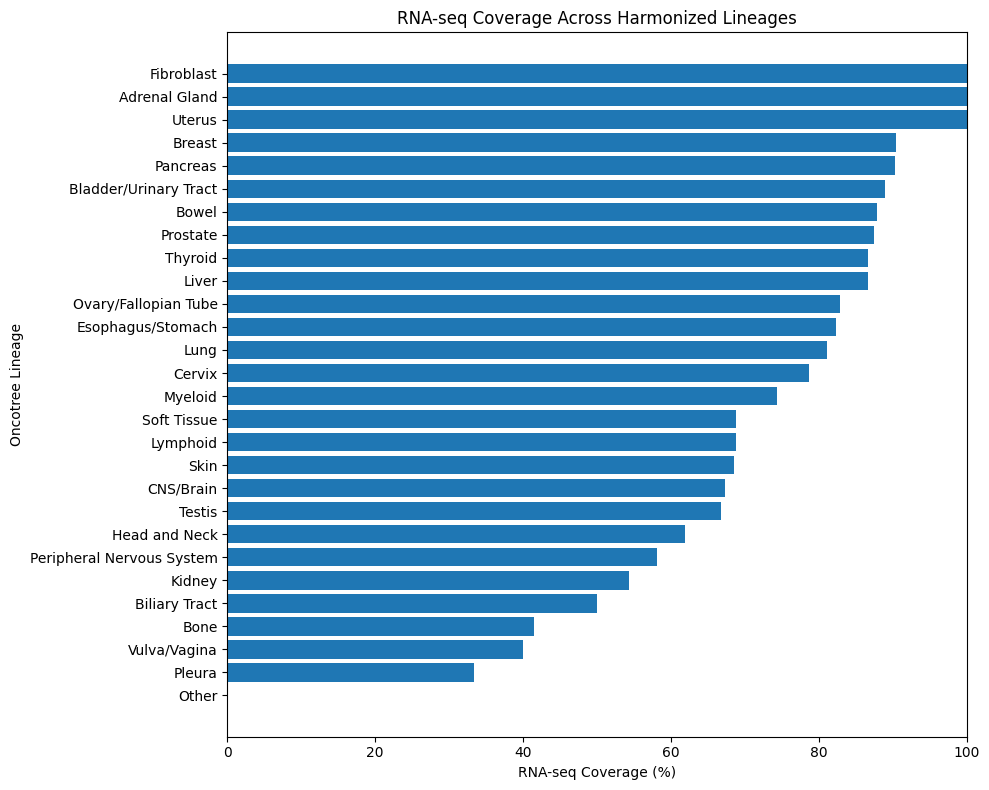

In [52]:
plot_df = lineage_coverage.sort_values("CoveragePct")

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["OncotreeLineage"],
    plot_df["CoveragePct"]
)

plt.xlabel("RNA-seq Coverage (%)")
plt.ylabel("Oncotree Lineage")
plt.title("RNA-seq Coverage Across Harmonized Lineages")

plt.xlim(0, 100)

plt.tight_layout()
plt.show()

RNA-seq availability represented the primary source of model attrition within the harmonized DepMap–GDSC universe.

Coverage was not uniformly distributed across lineages. Several lineages showed substantial reductions in RNA-seq availability, including Pleura, Bone, Kidney, Peripheral Nervous System, Head and Neck, CNS/Brain, and Lymphoid models.

Consequently, the final transcriptomic-pharmacogenomic cohort may exhibit lineage-specific representation biases that should be considered during downstream analyses and validation procedures.

In [53]:
lineage_coverage.describe()

,HarmonizedModels,ExpressionModels,MissingModels,CoveragePct
count,28.000000,28.000000,28.000000,28.000000
mean,34.571429,25.500000,9.071429,71.314286
std,37.403138,29.296062,10.055139,23.084670
min,1.000000,0.000000,0.000000,0.000000
25%,12.500000,7.000000,2.000000,60.950000
50%,26.000000,16.500000,5.000000,76.500000
75%,44.500000,34.750000,14.500000,87.575000
max,169.000000,137.000000,39.000000,100.000000


In [54]:
lineage_coverage["CoveragePct"].median()

np.float64(76.5)

| Metric                   |  Valor |
| ------------------------ | -----: |
| Harmonized universe      |    968 |
| Models with RNA-seq      |    715 |
| Global RNA coverage      | 73.86% |
| Mean lineage coverage    | 71.46% |
| Median lineage coverage  | 76.90% |
| Minimum lineage coverage |   0.0% |
| Maximum lineage coverage | 100.0% |


RNA-seq availability was heterogeneous across lineages.

While the overall RNA-seq coverage reached 73.9% of the harmonized model universe, lineage-specific coverage ranged from 0% to 100%, with a median lineage coverage of 76.9%.

This indicates that transcriptomic data loss is not uniformly distributed across cancer lineages and may introduce lineage-specific representation biases in downstream analyses.

---

## Multi-omics overlap

Individual data-layer coverage does not guarantee that the same models
are represented across all molecular and pharmacological resources.

To define the final integrated modeling cohort, overlap between data
layers is assessed at the model level.

Particular attention is given to expression data, mutation data,
omics profile availability, and pharmacological response coverage,
as these resources will support downstream transcriptomic and
pharmacogenomic analyses.

In [55]:
# =============================================================================
# Model sets by data layer
# =============================================================================

harmonized_models_set = set(
    harmonized_models["ModelID"]
)

expression_models_set = (
    harmonized_models_set
    & expr_models
)

mutation_models_set = (
    harmonized_models_set
    & mut_models
)

omics_models_set = (
    harmonized_models_set
    & omics_models
)

drug_response_models_set = (
    harmonized_models_set
    & gdsc_models
)

print(f"Harmonized universe : {len(harmonized_models_set)}")
print(f"Expression          : {len(expression_models_set)}")
print(f"Mutations           : {len(mutation_models_set)}")
print(f"Omics Profiles      : {len(omics_models_set)}")
print(f"Drug Response       : {len(drug_response_models_set)}")

Harmonized universe : 968
Expression          : 714
Mutations           : 959
Omics Profiles      : 960
Drug Response       : 968


In [56]:
# =============================================================================
# Pairwise and multi-layer overlaps
# =============================================================================

overlap_summary = pd.DataFrame({
    "Overlap": [
        "Expression ∩ Mutations",
        "Expression ∩ Omics Profiles",
        "Expression ∩ Drug Response",
        "Mutations ∩ Drug Response",
        "Expression ∩ Mutations ∩ Drug Response",
        "Expression ∩ Mutations ∩ Omics Profiles",
        "Expression ∩ Mutations ∩ Omics Profiles ∩ Drug Response"
    ],
    "Models": [
        len(expression_models_set & mutation_models_set),
        len(expression_models_set & omics_models_set),
        len(expression_models_set & drug_response_models_set),
        len(mutation_models_set & drug_response_models_set),
        len(expression_models_set & mutation_models_set & drug_response_models_set),
        len(expression_models_set & mutation_models_set & omics_models_set),
        len(expression_models_set & mutation_models_set & omics_models_set & drug_response_models_set),
    ]
})

overlap_summary["RetentionPct"] = (
    overlap_summary["Models"]
    / len(harmonized_models_set)
    * 100
).round(2)

overlap_summary

,Overlap,Models,RetentionPct
0,Expression ∩ Mutations,713,73.66
1,Expression ∩ Omics Profiles,714,73.76
2,Expression ∩ Drug Response,714,73.76
3,Mutations ∩ Drug Response,959,99.07
4,Expression ∩ Mutations ∩ Drug Response,713,73.66
5,Expression ∩ Mutations ∩ Omics Profiles,713,73.66
6,Expression ∩ Mutations ∩ Omics Profiles ∩ Drug...,713,73.66


### Cohort retention analysis

The impact of sequential inclusion criteria was evaluated to quantify model retention from the harmonized universe to the final integrated modeling cohort.

This analysis identifies the data layers responsible for model attrition and formalizes the final cohort definition used in downstream analyses.

In [57]:
retention_summary = pd.DataFrame({
    "Step": [
        "Harmonized universe",
        "Expression available",
        "Mutation available",
        "Omics profile available",
        "Drug response available",
        "Final integrated cohort"
    ],
    "Models": [
        968,
        714,
        713,
        713,
        713,
        713
    ]
})

retention_summary["RetentionPct"] = (
    retention_summary["Models"]
    / retention_summary.loc[0, "Models"]
    * 100
).round(2)

retention_summary

,Step,Models,RetentionPct
0,Harmonized universe,968,100.00
1,Expression available,714,73.76
2,Mutation available,713,73.66
3,Omics profile available,713,73.66
4,Drug response available,713,73.66
5,Final integrated cohort,713,73.66


Integrated modeling cohort:
- Harmonized DepMap–GDSC model
- RNA-seq expression available
- Somatic mutation data available
- Omics profile metadata available
- Pharmacological response available

Final cohort size: 713 models

---

In [58]:
# =============================================================================
# Final integrated modeling cohort
# =============================================================================

final_integrated_model_ids = (
    expression_models_set
    & mutation_models_set
    & omics_models_set
    & drug_response_models_set
)

integrated_modeling_cohort = (
    harmonized_models
    .loc[harmonized_models["ModelID"].isin(final_integrated_model_ids)]
    .copy()
    .sort_values("ModelID")
    .reset_index(drop=True)
)

integrated_modeling_cohort.shape

(713, 8)

In [59]:
# =============================================================================
# Model-level layer coverage table
# =============================================================================

model_layer_coverage = coverage_df.copy()

model_layer_coverage["in_integrated_modeling_cohort"] = (
    model_layer_coverage["ModelID"].isin(final_integrated_model_ids)
)

model_layer_coverage = (
    model_layer_coverage
    .sort_values("ModelID")
    .reset_index(drop=True)
)

model_layer_coverage.head()

,ModelID,SangerModelID,COSMICID,CellLineName,OncotreeLineage,OncotreePrimaryDisease,OncotreeSubtype,CCLEName,has_expression,has_mutations,has_omics_profile,in_integrated_modeling_cohort
0,ACH-000001,SIDM00105,905933.0,NIH:OVCAR-3,Ovary/Fallopian Tube,Ovarian Epithelial Tumor,High-Grade Serous Ovarian Cancer,NIHOVCAR3_OVARY,True,True,True,True
1,ACH-000002,SIDM00829,905938.0,HL-60,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HL60_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,True,True,True,True
2,ACH-000004,SIDM00594,907053.0,HEL,Myeloid,Acute Myeloid Leukemia,Acute Myeloid Leukemia,HEL_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,True,True,True,True
3,ACH-000006,SIDM01023,908148.0,MONO-MAC-6,Myeloid,Acute Myeloid Leukemia,Acute Monoblastic/Monocytic Leukemia,MONOMAC6_HAEMATOPOIETIC_AND_LYMPHOID_TISSUE,True,True,True,True
4,ACH-000007,SIDM00677,907795.0,LS513,Bowel,Colorectal Adenocarcinoma,Colon Adenocarcinoma,LS513_LARGE_INTESTINE,True,True,True,True


In [60]:
# =============================================================================
# Export artifacts
# =============================================================================

model_layer_coverage.to_csv(
    METADATA_DIR / "302_model_layer_coverage.csv",
    index=False
)

integrated_modeling_cohort.to_csv(
    METADATA_DIR / "302_integrated_modeling_cohort.csv",
    index=False
)

retention_summary.to_csv(
    METADATA_DIR / "302_cohort_summary.csv",
    index=False
)

print("Exported:")
print(METADATA_DIR / "302_model_layer_coverage.csv")
print(METADATA_DIR / "302_integrated_modeling_cohort.csv")
print(METADATA_DIR / "302_cohort_summary.csv")

Exported:
C:\Users\paula\OneDrive\Documentos\Proyectos\pancancer-epigenetics\data\interim\metadata\302_model_layer_coverage.csv
C:\Users\paula\OneDrive\Documentos\Proyectos\pancancer-epigenetics\data\interim\metadata\302_integrated_modeling_cohort.csv
C:\Users\paula\OneDrive\Documentos\Proyectos\pancancer-epigenetics\data\interim\metadata\302_cohort_summary.csv


## Summary

This notebook defined the final integrated modeling cohort for downstream multi-omic and pharmacogenomic analyses.

Starting from 968 harmonized DepMap–GDSC models, RNA-seq availability represented the main source of model attrition. Expression data were available for 714 models, while mutation data, omics profile metadata, and GDSC pharmacological response showed near-complete coverage.

The final integrated modeling cohort includes 713 models with expression, mutation, omics profile metadata, and pharmacological response data.

RNA-seq coverage was heterogeneous across lineages, indicating that downstream transcriptomic analyses should account for lineage-specific representation biases.

No resistance-like phenotypes, drug-response labels, signatures, clustering, or predictive models were defined in this notebook.